# Case Study: Implementing Variational Autoencoders (VAEs) with TensorFlow and Keras on Ship Data

## Problem Statement
The goal is to generate realistic synthetic ship images using **Variational Autoencoders (VAEs)**. This technique can be used to augment datasets in scenarios where acquiring real data is expensive or time-consuming. We will leverage the CIFAR-10 dataset, filtering it to include only images of ships.

---

## Dataset
The **CIFAR-10 dataset** includes 60,000 32x32 color images in 10 classes, with 6,000 images per class. We will:
- Extract only the **ship class** (label 8).
- Normalize the pixel values to the range [0, 1].
- Use 80% of the ship images for training and 20% for validation.

---

## Variational Autoencoders (VAEs)
A **Variational Autoencoder (VAE)** consists of the following components:
1. **Encoder**: Compresses the input data into a lower-dimensional latent space.
2. **Latent Space**: Encodes a distribution (mean and variance) instead of a single point.
3. **Decoder**: Reconstructs the data from the latent representation.

### Key Objectives:
- Minimize the **reconstruction loss** between input and generated data.
- Ensure the latent space follows a standard normal distribution using **Kullback-Leibler (KL) divergence**.

---

## Implementation

### Step 1: Import Libraries


In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


### Step 2: Load and Preprocess the Dataset

In [2]:
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Filter only the ship class (label 8)
ship_train = x_train[y_train.flatten() == 8]
ship_test = x_test[y_test.flatten() == 8]

# Normalize the pixel values to [0, 1]
ship_train = ship_train.astype('float32') / 255.0
ship_test = ship_test.astype('float32') / 255.0

# Combine train and test sets, then split into training and validation sets
ship_data = np.concatenate([ship_train, ship_test], axis=0)
x_train, x_val = np.split(ship_data, [int(0.8 * len(ship_data))])


### Step 3: Define the VAE Components

In [3]:
latent_dim = 32  # Dimensionality of the latent space

# Encoder Model
def build_encoder(latent_dim):
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inputs)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    return keras.Model(inputs, [z_mean, z_log_var], name='encoder')

encoder = build_encoder(latent_dim)
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    262,208 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 285,760 (1.09 MB)

 Trainable params: 285,760 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Sampling Layer

In [4]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


### Step 5: Define the Decoder

In [5]:
def build_decoder(latent_dim):
    inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 64, activation='relu')(inputs)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    outputs = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)
    return keras.Model(inputs, outputs, name='decoder')

decoder = build_decoder(latent_dim)
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │       135,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,427 (747.76 KB)

 Trainable params: 191,427 (747.76 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Build the VAE Model

In [6]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = self.sampling((z_mean, z_log_var))
        reconstructed = self.decoder(z)
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        self.add_loss(kl_loss)
        return reconstructed

vae = VAE(encoder, decoder)


### Step 7: Compile and Train the VAE

In [7]:
# Compile the model
vae.compile(optimizer='adam', loss='mse')

# Train the model
history = vae.fit(x_train, x_train, epochs=100, batch_size=64, validation_data=(x_val, x_val))


Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0585 - val_loss: 0.0540
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0547 - val_loss: 0.0529
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0547 - val_loss: 0.0530
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0545 - val_loss: 0.0532
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0544 - val_loss: 0.0528
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0544 - val_loss: 0.0527
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0544 - val_loss: 0.0525
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0543 - val_loss: 0.0530
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0543 - val_loss: 0.0525
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0542 - val_loss: 0.0528
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0542 - val_loss: 0.0527
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

### Step 8: Visualize Training Loss

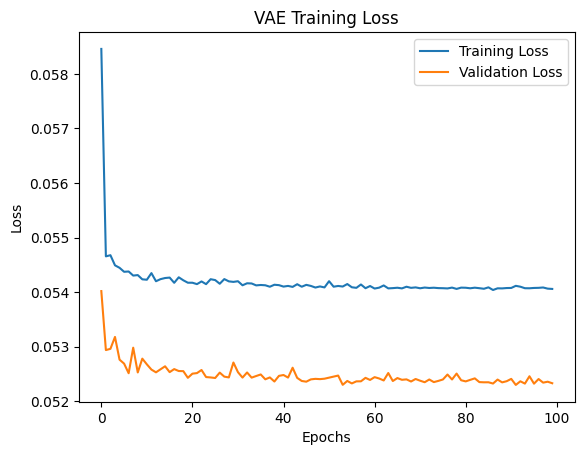

In [8]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VAE Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Step 9: Generate and Visualize New Ship Images

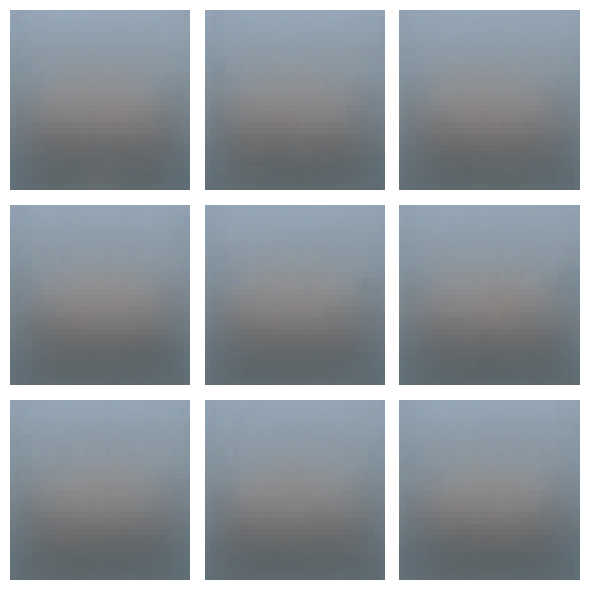

In [9]:
def generate_and_plot(vae, n_samples=9):
    z = tf.random.normal(shape=(n_samples, latent_dim))
    generated_imgs = vae.decoder(z).numpy()

    plt.figure(figsize=(6, 6))
    for i in range(n_samples):
        plt.subplot(3, 3, i + 1)
        plt.imshow(generated_imgs[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Generate synthetic ship images
generate_and_plot(vae)


## Results and Conclusion
- The VAE was trained on ship images extracted from the CIFAR-10 dataset.
- The generated images resemble real ships, demonstrating the effectiveness of VAEs for synthetic image generation.
- This approach can be extended to augment datasets for other applications.